<a href="https://colab.research.google.com/github/abeliyasya/churn_analysis/blob/main/ML_Churn_LightGBM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    roc_auc_score,
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


In [ ]:
f = pd.read_csv("Churn.csv", sep=';')
print(df.info())
print(df.head())
X = df.drop("Exited", axis=1)
y = df["Exited"]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB
None
   CreditScore Geography  Gender  Age  Tenure    Balance  NumOfProducts  \
0          619    France  Female   42       2       0.00              1   
1          608     Spain  Female   41       1   83807.86              1   


In [ ]:
X = df.drop(columns=['Exited'])
y = df['Exited']

print("\nJumlah fitur:", X.shape[1])
print("Jumlah observasi:", X.shape[0])



Jumlah fitur: 10
Jumlah observasi: 10000


In [ ]:
df.isnull().sum()


,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0
HasCrCard,0
IsActiveMember,0
EstimatedSalary,0


In [ ]:
numeric_X = X.select_dtypes(include=np.number)
corr_matrix = numeric_X.corr()

print("\n=== Matriks Korelasi (ringkas) ===")
print(corr_matrix.round(2))


=== Matriks Korelasi (ringkas) ===
                 CreditScore   Age  Tenure  Balance  NumOfProducts  HasCrCard  \
CreditScore             1.00 -0.00    0.00     0.01           0.01      -0.01   
Age                    -0.00  1.00   -0.01     0.03          -0.03      -0.01   
Tenure                  0.00 -0.01    1.00    -0.01           0.01       0.02   
Balance                 0.01  0.03   -0.01     1.00          -0.30      -0.01   
NumOfProducts           0.01 -0.03    0.01    -0.30           1.00       0.00   
HasCrCard              -0.01 -0.01    0.02    -0.01           0.00       1.00   
IsActiveMember          0.03  0.09   -0.03    -0.01           0.01      -0.01   
EstimatedSalary        -0.00 -0.01    0.01     0.01           0.01      -0.01   

                 IsActiveMember  EstimatedSalary  
CreditScore                0.03            -0.00  
Age                        0.09            -0.01  
Tenure                    -0.03             0.01  
Balance                   -0.0

In [ ]:
# Statistik deskriptif fitur numerik
desc_stats = df.describe()
print(desc_stats)


        CreditScore           Age        Tenure        Balance  NumOfProducts  \
count  10000.000000  10000.000000  10000.000000   10000.000000   10000.000000   
mean     650.528800     38.921800      5.012800   76485.889288       1.530200   
std       96.653299     10.487806      2.892174   62397.405202       0.581654   
min      350.000000     18.000000      0.000000       0.000000       1.000000   
25%      584.000000     32.000000      3.000000       0.000000       1.000000   
50%      652.000000     37.000000      5.000000   97198.540000       1.000000   
75%      718.000000     44.000000      7.000000  127644.240000       2.000000   
max      850.000000     92.000000     10.000000  250898.090000       4.000000   

         HasCrCard  IsActiveMember  EstimatedSalary        Exited  
count  10000.00000    10000.000000     10000.000000  10000.000000  
mean       0.70550        0.515100    100090.239881      0.203700  
std        0.45584        0.499797     57510.492818      0.402769 

In [ ]:
df.groupby('Exited').mean(numeric_only=True)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
Exited,,,,,,,,
0,651.853196,37.408389,5.033279,72745.296779,1.544267,0.707146,0.554565,99738.391772
1,645.351497,44.837997,4.932744,91108.539337,1.475209,0.699067,0.360825,101465.677531


In [ ]:
churn_dist = df['Exited'].value_counts()
print(churn_dist)


Exited
0    7963
1    2037
Name: count, dtype: int64


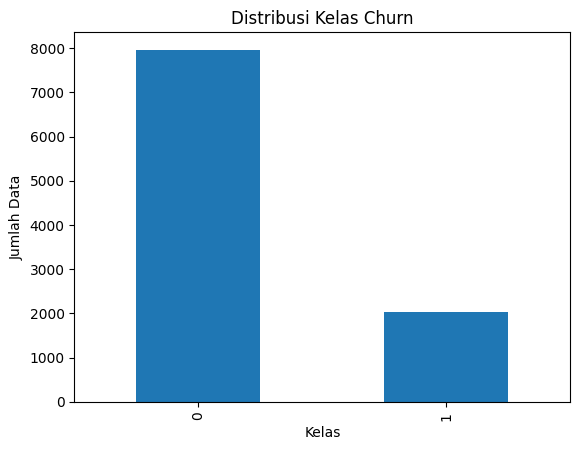

In [ ]:
plt.figure()
df['Exited'].value_counts().plot(kind='bar')
plt.xlabel('Kelas')
plt.ylabel('Jumlah Data')
plt.title('Distribusi Kelas Churn')
plt.show()


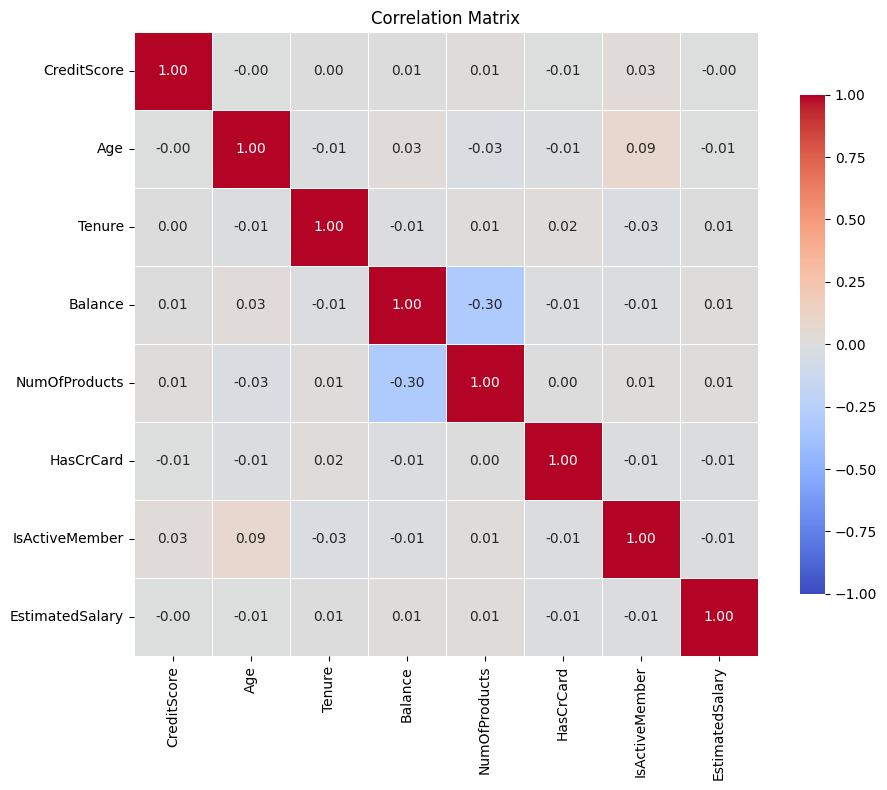

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,          # tampilkan angka
    fmt=".2f",           # 2 angka desimal
    cmap="coolwarm",     # warna kontras
    vmin=-1, vmax=1,     # skala korelasi
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


In [ ]:
print("\n=== Distribusi Kelas Training ===")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))

print("\n=== Distribusi Kelas Testing ===")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True))



=== Distribusi Kelas Training ===
Exited
0    5574
1    1426
Name: count, dtype: int64
Exited
0    0.796286
1    0.203714
Name: proportion, dtype: float64

=== Distribusi Kelas Testing ===
Exited
0    2389
1     611
Name: count, dtype: int64
Exited
0    0.796333
1    0.203667
Name: proportion, dtype: float64


In [ ]:
n_negative = (y_train == 0).sum()
n_positive = (y_train == 1).sum()

scale_pos_weight = n_negative / n_positive

print("\nscale_pos_weight:", scale_pos_weight)



scale_pos_weight: 3.908835904628331


In [ ]:
cat_cols = X.select_dtypes(include='object').columns
for col in cat_cols:
    X[col] = X[col].astype('category')


In [ ]:
param_grid = {
    'num_leaves': [31, 40, 50],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 300],
    'feature_fraction': [0.6, 0.8, 1.0],
    'bagging_fraction': [0.6, 0.8, 1.0],
    'lambda_l1': [0, 0.1, 0.5],
    'lambda_l2': [0, 0.1, 0.5]
}

# Convert categorical columns in X_train and X_test to 'category' dtype
# This is necessary because X_train and X_test were created before X's categorical columns were converted.
for col in X_train.select_dtypes(include='object').columns:
    X_train[col] = X_train[col].astype('category')
for col in X_test.select_dtypes(include='object').columns:
    X_test[col] = X_test[col].astype('category')

lgbm = lgb.LGBMClassifier(
    objective='binary',
    scale_pos_weight=scale_pos_weight, # Use the numerical variable, not a string literal
    boosting_type='gbdt',
    random_state=42
)

grid_search = GridSearchCV(
    estimator=lgbm,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("\nBest Parameters Ditemukan:")
print(grid_search.best_params_)
print(f"Best AUC (Train): {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 6561 candidates, totalling 19683 fits
[LightGBM] [Warning] feature_fraction is set=0.6, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6
[LightGBM] [Warning] lambda_l2 is set=0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0
[LightGBM] [Warning] lambda_l1 is set=0.1, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.1
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
[LightGBM] [Warning] feature_fraction is set=0.6, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6
[LightGBM] [Warning] lambda_l2 is set=0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0
[LightGBM] [Warning] lambda_l1 is set=0.1, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.1
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
[LightGBM] [Info] Number of positive: 1426, nu

In [ ]:
print("\n=== GRID SEARCH START ===")
start_time = time.time()

grid_search.fit(X_train, y_train)

end_time = time.time()
training_time = end_time - start_time



=== GRID SEARCH START ===
Fitting 3 folds for each of 6561 candidates, totalling 19683 fits
[LightGBM] [Warning] feature_fraction is set=0.6, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6
[LightGBM] [Warning] lambda_l2 is set=0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0
[LightGBM] [Warning] lambda_l1 is set=0.1, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.1
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
[LightGBM] [Warning] feature_fraction is set=0.6, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6
[LightGBM] [Warning] lambda_l2 is set=0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0
[LightGBM] [Warning] lambda_l1 is set=0.1, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.1
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
[LightGBM] [Info] N

In [ ]:
print("\n=== BEST PARAMETERS ===")
for k, v in grid_search.best_params_.items():
    print(f"{k}: {v}")

print(f"\nBest CV ROC-AUC: {grid_search.best_score_:.4f}")
print(f"Total Training Time (seconds): {training_time:.2f}")




=== BEST PARAMETERS ===
bagging_fraction: 0.6
feature_fraction: 0.6
lambda_l1: 0.1
lambda_l2: 0
learning_rate: 0.01
max_depth: 5
n_estimators: 300
num_leaves: 40

Best CV ROC-AUC: 0.8622
Total Training Time (seconds): 3727.40


In [ ]:
# Use the best estimator found by GridSearchCV for predictions
best_lgbm_model = grid_search.best_estimator_

# TRAIN
y_train_pred = best_lgbm_model.predict(X_train)
y_train_prob = best_lgbm_model.predict_proba(X_train)[:, 1]

# TEST
y_test_pred = best_lgbm_model.predict(X_test)
y_test_prob = best_lgbm_model.predict_proba(X_test)[:, 1]

[LightGBM] [Warning] feature_fraction is set=0.6, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6
[LightGBM] [Warning] lambda_l2 is set=0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0
[LightGBM] [Warning] lambda_l1 is set=0.1, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.1
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
[LightGBM] [Warning] feature_fraction is set=0.6, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6
[LightGBM] [Warning] lambda_l2 is set=0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0
[LightGBM] [Warning] lambda_l1 is set=0.1, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.1
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
[LightGBM] [Warning] feature_fraction is set=0.6, colsample_bytree=1.0 will be ignored. Current value: feature_f

In [ ]:
def print_metrics(y_true, y_pred, y_prob, label):
    print(f"\n=== {label} PERFORMANCE ===")
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall   : {recall_score(y_true, y_pred):.4f}")
    print(f"F1-score : {f1_score(y_true, y_pred):.4f}")
    print(f"ROC-AUC  : {roc_auc_score(y_true, y_prob):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

print_metrics(y_train, y_train_pred, y_train_prob, "TRAIN")
print_metrics(y_test, y_test_pred, y_test_prob, "TEST")



=== TRAIN PERFORMANCE ===
Accuracy : 0.8249
Precision: 0.5485
Recall   : 0.7924
F1-score : 0.6483
ROC-AUC  : 0.8985

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.83      0.88      5574
           1       0.55      0.79      0.65      1426

    accuracy                           0.82      7000
   macro avg       0.74      0.81      0.77      7000
weighted avg       0.86      0.82      0.84      7000


=== TEST PERFORMANCE ===
Accuracy : 0.8183
Precision: 0.5378
Recall   : 0.7676
F1-score : 0.6325
ROC-AUC  : 0.8799

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.83      0.88      2389
           1       0.54      0.77      0.63       611

    accuracy                           0.82      3000
   macro avg       0.74      0.80      0.76      3000
weighted avg       0.85      0.82      0.83      3000



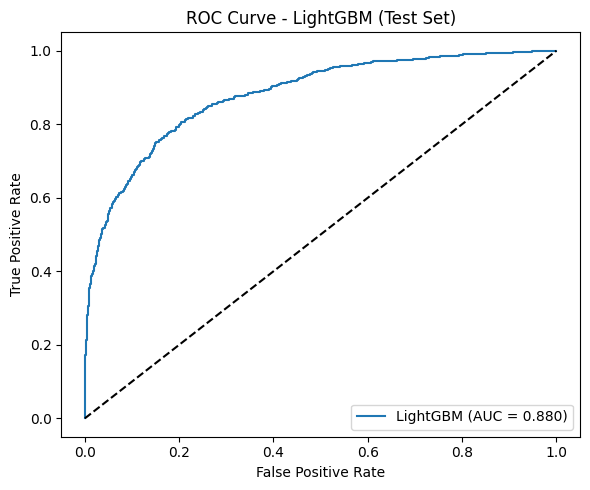

In [ ]:
from sklearn.metrics import roc_curve

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)
auc_value = roc_auc_score(y_test, y_test_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'LightGBM (AUC = {auc_value:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - LightGBM (Test Set)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


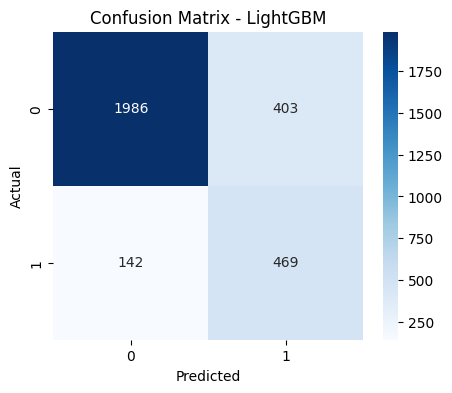

In [ ]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - LightGBM")
plt.show()

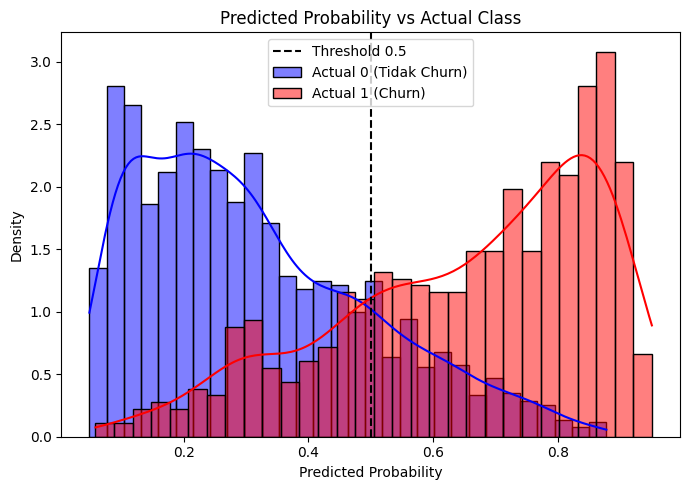

In [ ]:
plt.figure(figsize=(7,5))
sns.histplot(
    y_test_prob[y_test == 0],
    bins=30,
    color='blue',
    label='Actual 0 (Tidak Churn)',
    stat='density',
    kde=True
)

sns.histplot(
    y_test_prob[y_test == 1],
    bins=30,
    color='red',
    label='Actual 1 (Churn)',
    stat='density',
    kde=True
)

plt.axvline(0.5, color='black', linestyle='--', label='Threshold 0.5')
plt.xlabel('Predicted Probability')
plt.ylabel('Density')
plt.title('Predicted Probability vs Actual Class')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
importance = best_lgbm_model.feature_importances_
feature_names = X.columns

vimp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print("\n=== Feature Importance ===")
print(vimp_df)


=== Feature Importance ===
           Feature  Importance
5          Balance        1434
3              Age        1333
9  EstimatedSalary        1105
0      CreditScore        1035
6    NumOfProducts         718
1        Geography         585
4           Tenure         455
2           Gender         338
8   IsActiveMember         307
7        HasCrCard          36


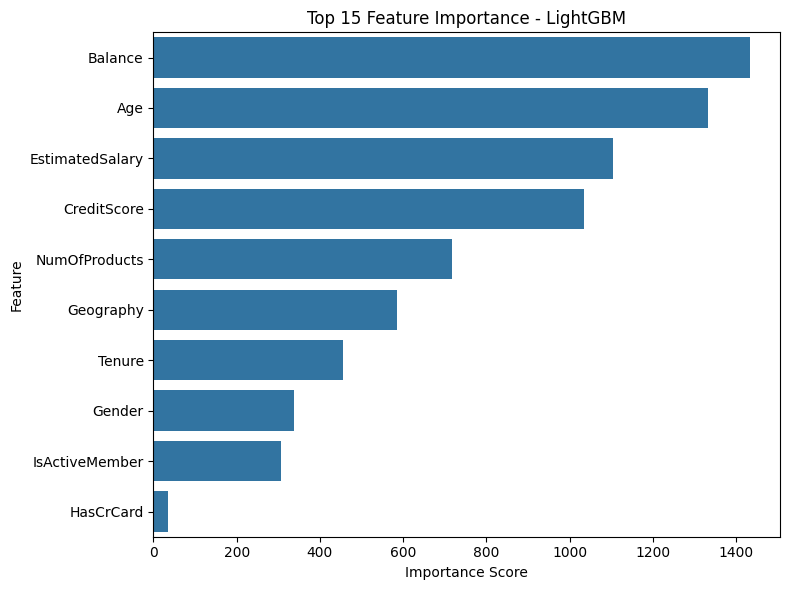

In [ ]:
plt.figure(figsize=(8,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=vimp_df.head(15)
)
plt.title('Top 15 Feature Importance - LightGBM')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()